In [34]:
import torch
import numpy as np

from dinosaw.helpers import add_custom_font, get_model #, get_features
from dinosaw.linear_probe import do_linear_probe, RampTypes, LinearProbeResult, get_ramp, gen_sample_mask
from dinosaw.models.vit_wrapper import PretrainedViTWrapper, MODEL_LIST
import dinosaw.utils as utils

from os import listdir
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda:0'

In [35]:
S=16
HALF=False
Dv3=True
N=list(range(11))

In [36]:
# selected_model = 'alibi_dv2_cb_l-2'
# selected_model = 'alibi_dv2_cb_l_j_mo'
# selected_model = 'alibi_dv2_cb_l_j-2'
# selected_model = 'alibi_dv2_cb_l_j_roll-2'
selected_model = 'dv3'
# model = get_model(selected_model, '../../trained_models', device=DEVICE, conf_path='../../dinov3')
#model = get_model(selected_model, '../../trained_models', device=DEVICE)

model = PretrainedViTWrapper(
            MODEL_LIST[4],
            stride=S,
            add_flash_attn=False,
            device=DEVICE,
            chk_path="../../trained_models/dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth",
            conf_path="../../dinov3"
        )
model = model.eval()
if HALF:
    model = model.half()

n_dims = 768 if '_b' in selected_model else 384
# n_dims = 256

In [37]:
def get_feature_list(
    model: PretrainedViTWrapper,
    pil_img: Image.Image,
    channel_last: bool = False,
    channel_blank: bool = False,
    to_half: bool = False,
    device: str = "cuda:0",
    S: int = 14,
    N: int = 11
) -> list[np.ndarray]:
    tr = utils.closest_resize(pil_img.height, pil_img.width, model.stride)
    img_tensor = utils.convert_image(pil_img, tr, device_str=device, to_half=to_half)
    with torch.no_grad():
        embs = model.get_intermediate_layers(img_tensor, n=N, Dv3=Dv3)
    embs_np = [utils.to_numpy(emb.squeeze(0)) for emb in embs]
    if channel_blank:
        channels_to_blank = [47, 113, 117, 359]
        for emb_np in embs_np:
            emb_np[channels_to_blank, :, :] = 0
    if channel_last:
        embs_np = [np.transpose(emb_np, (1, 2, 0)) for emb_np in embs_np]

    return embs_np

In [38]:
ds_folder = 'data/linear_probe/homog_micros'
image_files = [f for f in listdir(ds_folder)]
n_imgs = len(image_files)

features = []
for img_file in image_files:
    img_path = f'{ds_folder}/{img_file}'
    img = Image.open(img_path).convert('RGB')
    feat_list = get_feature_list(model, img, device=DEVICE, channel_last=True, S=S, N=N)
    features.append(feat_list)

In [39]:
# preview_folder = 'data/linear_probe/'
# preview_img_names = ['black_square_518.png', 'bulldog_518.png', 'edinburgh.png', '000.png']
# preview_feats = []
# preview_imgs: list[Image.Image] = []

# for fname in preview_img_names:
#     img_path = f'{preview_folder}/{fname}'
#     img = Image.open(img_path).convert('RGB')
#     img = img.resize((518, 518))
#     feats = get_features(model, img, device=DEVICE, channel_last=True)
#     preview_imgs.append(img)
#     preview_feats.append(feats)


In [40]:
ramps: tuple[RampTypes, ...] = ('lr', 'ud', 'diag', 'radial')
ramps_to_results: dict[RampTypes, list[LinearProbeResult]] = {layer: {r: [] for r in ramps} for layer in range(len(N))}
MASK_CUTOFF_FRAC = 1
STEP = 6
RANDOM_MASK = True

for ramp in ramps:
    for layer in range(len(N)):
        for i in range(n_imgs):
            feats = features[i][layer]
            result = do_linear_probe(feats, ramp, probe_by_channel=True, mask_step=STEP, mask_cutoff_frac=MASK_CUTOFF_FRAC, random_mask=RANDOM_MASK)
            ramps_to_results[layer][ramp].append(result)

In [41]:
from skimage.transform import resize
def average_results(results: list[LinearProbeResult]) -> tuple[np.ndarray, np.ndarray, float, float, np.ndarray]:
    channel_scores_arr = np.array([res['per_channel_scores'] for res in results])
    mean_channel_scores = np.mean(channel_scores_arr, axis=0)
    std_channel_scores = np.std(channel_scores_arr, axis=0)

    scores_arr = np.array([res['stack_r_squared'] for res in results])
    mean_score = np.mean(scores_arr, axis=0)
    std_score = np.std(scores_arr, axis=0)

    n_pred_dims = results[0]['stack_pred'].shape[-1]
    mean_pred = np.zeros((34, 34, n_pred_dims))

    for res in results:
        pred = resize(res['stack_pred'], mean_pred.shape, order=1)
        mean_pred += pred / len(results)

    return mean_channel_scores, std_channel_scores, mean_score, std_score, mean_pred

In [42]:
def average_list_results(results, ramp = "lr"):
    list_mean_channel_scores, list_std_channel_scores, list_mean_score, list_std_score, list_mean_pred = [], [],[],[], []
    for layer_idx in range(len(N)):
        results_ = results[layer_idx][ramp]
        channel_scores_arr = np.array([res['per_channel_scores'] for res in results_])
        mean_channel_scores = np.mean(channel_scores_arr, axis=0)
        std_channel_scores = np.std(channel_scores_arr, axis=0)

        scores_arr = np.array([res['stack_r_squared'] for res in results_])
        mean_score = np.mean(scores_arr, axis=0)
        std_score = np.std(scores_arr, axis=0)

        n_pred_dims = results_[0]['stack_pred'].shape[-1]
        mean_pred = np.zeros((34, 34, n_pred_dims))

        for res in results_:
            pred = resize(res['stack_pred'], mean_pred.shape, order=1)
        mean_pred += pred / len(results_)
        
        list_mean_channel_scores.append(mean_channel_scores)
        list_mean_pred.append(mean_pred)
        list_mean_score.append(mean_score)
        list_std_channel_scores.append(std_channel_scores)
        list_std_score.append(std_score)
    return list_mean_channel_scores, list_std_channel_scores, list_mean_score, list_std_score, list_mean_pred


In [107]:
list_mean_channel_scores, list_std_channel_scores, list_mean_score, list_std_score, list_mean_pred = average_list_results(ramps_to_results)

In [53]:
def hide_axes(ax: plt.Axes):
    ax.set_xticks([])
    ax.set_yticks([])
    if hasattr(ax, 'set_zticks'):
        ax.set_zticks([])

In [108]:
realtive_position = [mean_channel_score - np.mean(mean_channel_score) for mean_channel_score in list_mean_channel_scores.copy()]

In [121]:
realtive_position[0].max(), list_mean_channel_scores[0].max()

(np.float64(0.02125175397011846), np.float64(-0.031058263837092825))

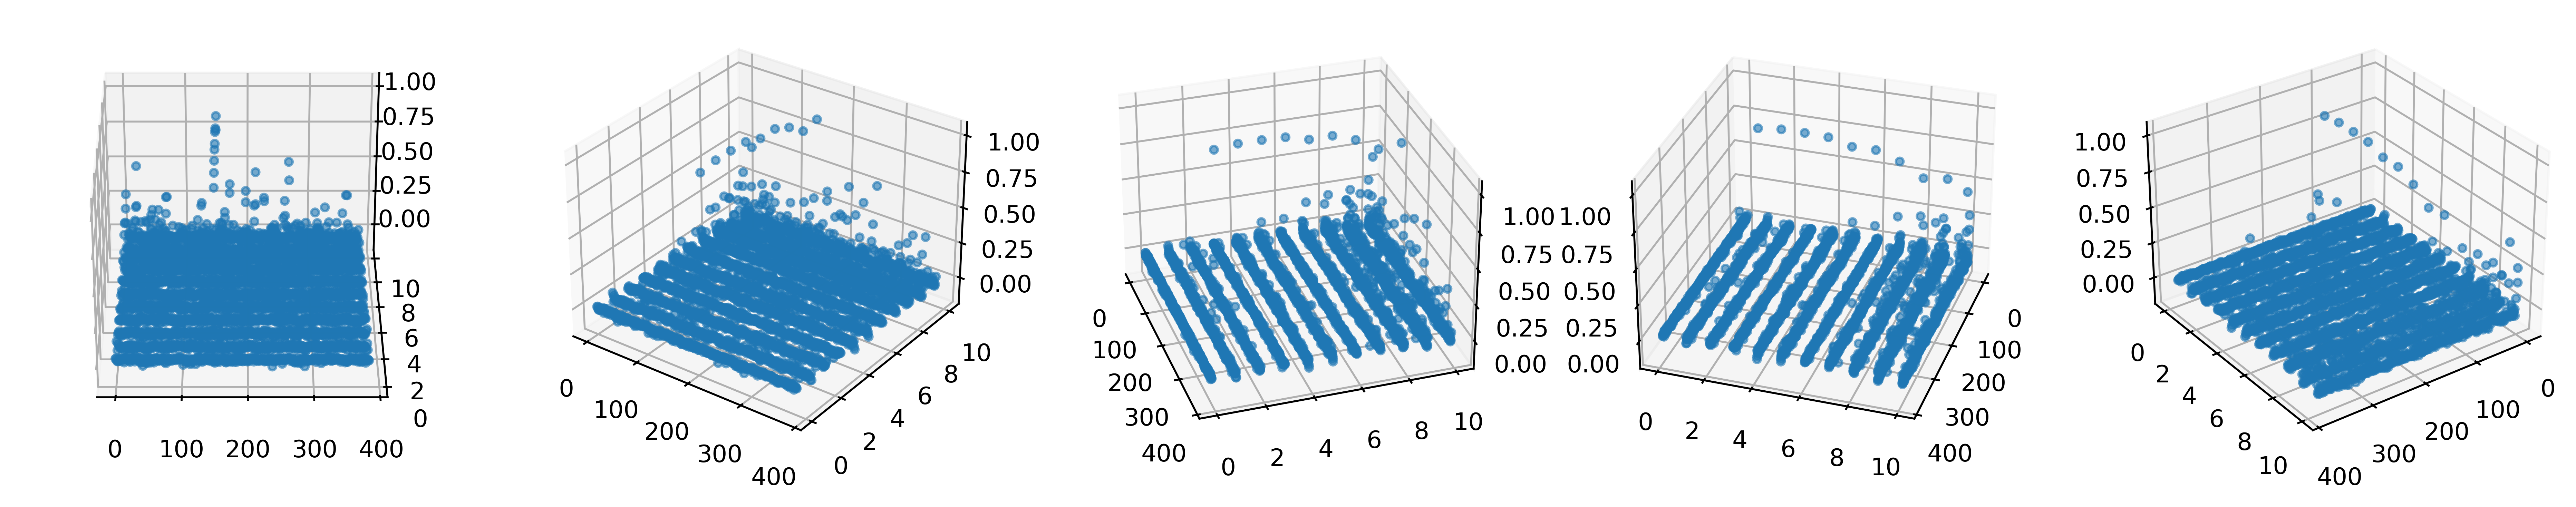

In [117]:
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
n_angles=5

x = N
y=range(384)
x,y = np.meshgrid(y,x)
# z=np.array(list_mean_channel_scores)
z=np.array(realtive_position)
# z = gaussian_filter1d(z, sigma=1.5, axis=1, mode='nearest')
fig = plt.figure(dpi=500, figsize=(19,5))
for i in range(2, n_angles + 2):
        ax = fig.add_subplot(1, 5, i-1, projection="3d")

        j = i - 2
        angle_deg = 270 + j * (180 // n_angles)

        ax.view_init(azim=angle_deg)

        ax.scatter(x, y, z, marker='o', s=10, alpha=0.6)
        # ax.plot_surface(x, y, z, alpha=0.6)

        # hide_axes(ax)

384

In [ ]:
def plot_row_of_embeddings(emb_2D: np.ndarray, axs: list[plt.Axes], n_angles: int=5):

    axs[1].imshow(emb_2D)
    hide_axes(axs[1])

    for i in range(2, n_angles + 2):
        ax = axs[i]

        j = i - 2
        angle_deg = 270 + j * (180 // n_angles)

        ax.view_init(azim=angle_deg)

        embed_flat = emb_2D.reshape(-1, 3)

        xs = embed_flat[:, 0] - 0.5
        ys = embed_flat[:, 1] - 0.5
        zs = embed_flat[:, 2] - 0.5

        colours = embed_flat
        ax.scatter(xs, ys, zs, marker='o', c=colours, s=10, alpha=0.6)

        hide_axes(ax)
    return 

384

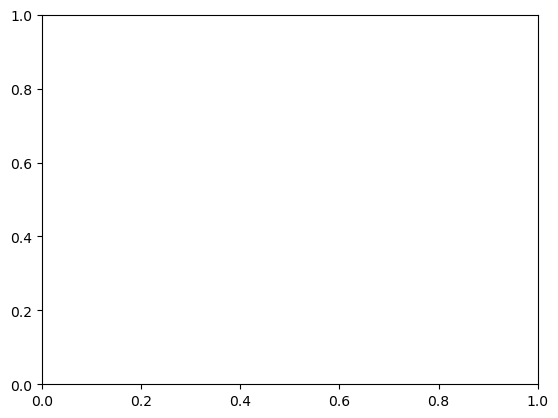

In [ ]:
fig, ax = plt.subplots(1,1)

In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

def add_red_square_overlay(ax: plt.Axes, mask: np.ndarray, sf_h: float, sf_w: int) -> None:
    patches: list[Rectangle] = []
    y_inds, x_inds  = np.nonzero(mask)
    for x, y in zip(x_inds, y_inds):
        rect = Rectangle((x - sf_w / 2, y - sf_h / 2), sf_w, sf_h)
        patches.append(rect)
    pc = PatchCollection(patches, color='red', facecolor='none')
    ax.add_collection(pc)

Can't load custom font: [Errno 2] No such file or directory: 'resources/fonts/Grotesk.ttf' 
lr: [149  31 133]
ud: [ 74 269 313]
diag: [149  74  31]
radial: [330 133 177]


NameError: name 'preview_imgs' is not defined

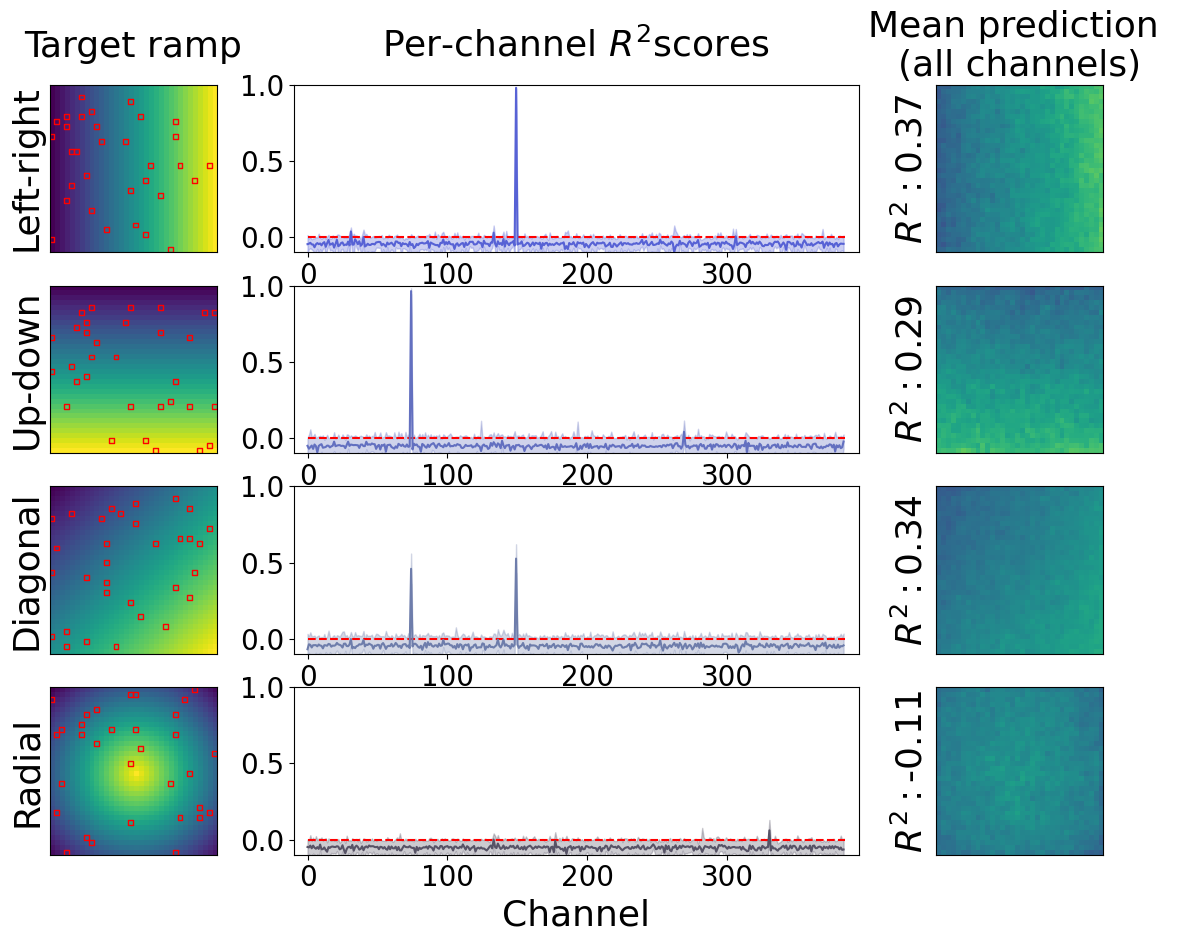

In [ ]:
#%%capture
n_rows, n_cols = 4, 9
TITLE_PAD = 20
FS = 26
add_custom_font('resources/fonts', 'Grotesk')
W, H = 3, 2.5

w_spacing = [1 for _ in range(n_cols)]
SPACE_ROW_IDXS = (4,)

FIG_B_COL_OFFSET = 1
FIG_B_W_COLS = 2
FIG_C_COL_OFFSET = FIG_B_COL_OFFSET + FIG_B_W_COLS + 2

w_spacing[4] = 0.2

w_spacing[FIG_C_COL_OFFSET:] = [0.7] * len(w_spacing[FIG_C_COL_OFFSET:])

fig = plt.figure(figsize=(W * n_cols, H * n_rows))
gs = GridSpec(n_rows, n_cols, figure=fig, width_ratios=w_spacing, wspace=0.12)
colors: dict[RampTypes, str] = {
    'lr': '#5762D5',
    'ud': '#6370C0',
    'diag': '#6E7DAB',
    'radial': '#575366',
}
ramp_to_title: dict[RampTypes, str] = {
    'lr': 'Left-right',
    'ud': 'Up-down',
    'diag': 'Diagonal',
    'radial': 'Radial',
}
# spacer_row = fig.add_subplot(gs[:, 5])


top_left_ramp_ax = None
for row, ramp in enumerate(ramps):
    h, w = 34, 34
    ramp_arr = get_ramp(ramp, h, w)
    ramp_ax = fig.add_subplot(gs[row, 0])
    ramp_ax.imshow(ramp_arr, cmap='viridis', vmin=0, vmax=1)

    mask = gen_sample_mask((h, w), ramp, STEP, MASK_CUTOFF_FRAC, random_mask=RANDOM_MASK)
    add_red_square_overlay(ramp_ax, mask, 1, 1)

    ramp_ax.set_xticks([])
    ramp_ax.set_yticks([])

    ramp_ax.set_ylabel(ramp_to_title[ramp], fontsize=FS)

    if row == 0:
        ramp_ax.set_title('Target ramp', fontsize=FS, pad=TITLE_PAD)
        top_left_ramp_ax = ramp_ax


worst_channels = []
for row, ramp in enumerate(ramps):
    ax = fig.add_subplot(gs[row, FIG_B_COL_OFFSET:FIG_B_COL_OFFSET + FIG_B_W_COLS])
    mean_channel_scores, std_channel_scores, mean_score, _, mean_pred = average_results(ramps_to_results[ramp])

    print(f"{ramp}: {np.argsort(-mean_channel_scores)[:3]}")
    worst_channels.extend(list(np.argsort(-mean_channel_scores)[:2]))

    ax.hlines(0, 0, n_dims, 'red', '--')

    ax.plot(mean_channel_scores, color=colors[ramp])
    ax.fill_between(
        np.arange(n_dims),
        mean_channel_scores - std_channel_scores,
        mean_channel_scores + std_channel_scores,
        color=colors[ramp],
        alpha=0.3,
    )
    ax.set_ylim(-0.1, 1)
    ax.set_xlim(0 -10, n_dims + 10)
    ax.tick_params(axis='both', labelsize=FS - 6)

    # ax.ticklabel_format(size=FS - 4)

    mean_pred_ax = fig.add_subplot(gs[row, FIG_B_COL_OFFSET + FIG_B_W_COLS])
    mean_pred_ax.imshow(mean_pred, cmap='viridis', vmin=0, vmax=1)

    if row == 0:
        ax.set_title('Per-channel ' + r'$R^2$' +  'scores', fontsize=FS, pad=TITLE_PAD)
        mean_pred_ax.set_title('Mean prediction \n(all channels)', fontsize=FS)
    elif row == len(ramps) - 1:
        ax.set_xlabel('Channel', fontsize=FS)
    

    mean_pred_ax.set_ylabel(f'$R^{2}:${mean_score:.2f}', fontsize=FS)
    mean_pred_ax.set_xticks([])
    mean_pred_ax.set_yticks([])

bad_channel_map = {
    'dv2': [47, 117, 359], 
    'dvt': [55, 113, 188],
    'dv2_b': [39, 354, 480], 
    'vit_b': [18, 390, 599], 
    'dv': [293, 61, 89 ], 
    'dv_b': [432, 266, 99 ], 
    'dv3': [149, 123, 74], 
    'clip_b': [69, 526, 554], 
    'eva02': [180, 192, 180], 
    'sam_b': [50, 27, 210],
    'deit': [173, 99, 302],
    'alibi_dv2_cb': [78, 73, 228],
}
bad_channels = bad_channel_map.get(selected_model, [47, 117, 359])

top_right_ax = None
for i, img in enumerate(preview_imgs):
    img_ax = fig.add_subplot(gs[i, FIG_C_COL_OFFSET])
    img_ax.imshow(img)
    img_ax.set_xticks([])
    img_ax.set_yticks([])
    if i == 0:
        top_right_ax = img_ax


    for j, ch in enumerate(bad_channels):
        ax = fig.add_subplot(gs[i, FIG_C_COL_OFFSET + j + 1])
        feats = preview_feats[i]
        selected_ch = feats[:, :, ch]
        ax.imshow(selected_ch, cmap='viridis')

        if i == 0:
            ax.set_title(f'Ch. {ch}', fontsize=FS, pad=TITLE_PAD)

        ax.set_xticks([])
        ax.set_yticks([])


labels = ['(a)', '(b)']
axes = [top_left_ramp_ax, top_right_ax]
# print(gs.subplots()[0, 0])
for i in range(2):
    ax = axes[i]
    ax.text(-0.55, 1.15, labels[i], transform=ax.transAxes,
            fontsize=FS+6, fontweight='bold', color='black')


plt.tight_layout(pad=0.05)
plt.savefig('saved/02.png', dpi=300, bbox_inches='tight')